# 2026-08-28 Stability

## Last time

* Conditioning and well posedness
* Relative and absolute errors

## Today

* Condition numbers
* Stability of algorithms
* Forward and backward error
* Demo: computing volume of a polygon

In [1]:
using Plots
default(linewidth=4)

# Conditioning

> What sort of functions cause small errors to become big?

Consider a function $f: X \to Y$ and define the **absolute condition number**
$$ \hat\kappa = \lim_{\delta \to 0} \max_{|\delta x| < \delta} \frac{|f(x + \delta x) - f(x)|}{|\delta x|} = \max_{\delta x} \frac{|\delta f|}{|\delta x|}. $$
If $f$ is differentiable, then $\hat\kappa = |f'(x)|$.

Floating point offers relative accuracy, so it's more useful to discuss **relative condition number**,
$$ \kappa = \max_{\delta x} \frac{|\delta f|/|f|}{|\delta x|/|x|}
= \max_{\delta x} \Big[ \frac{|\delta f|/|\delta x|}{|f| / |x|} \Big] $$
or, if $f$ is differentiable,
$$ \kappa = |f'(x)| \frac{|x|}{|f|} . $$

# Condition numbers

> $$ \kappa = |f'(x)| \frac{|x|}{|f|} $$

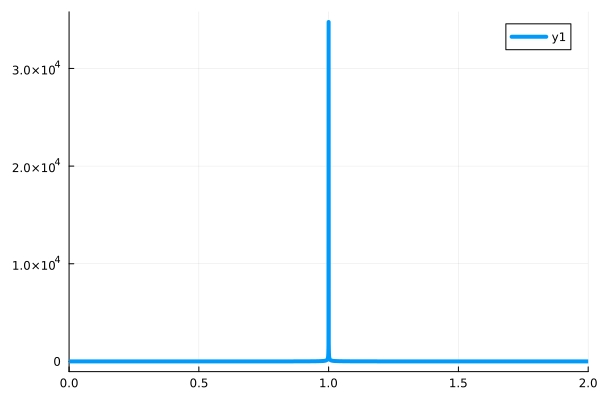

In [2]:
f(x) = x - 1; fp(x) = 1
plot(x -> abs(fp(x)) * abs(x) / abs(f(x)), xlims=(0, 2))

# Back to $f(x) = e^x - 1$

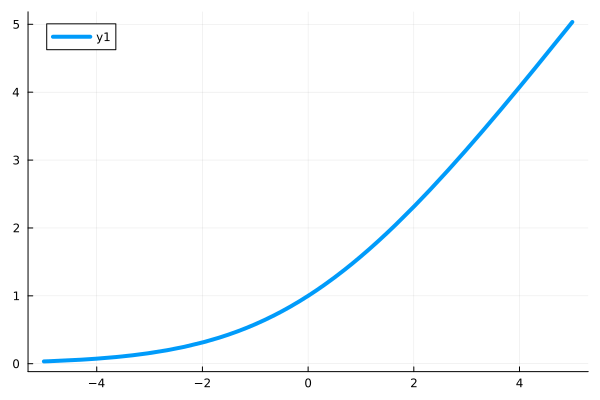

In [18]:
f(x) = exp(x) - 1
fp(x) = exp(x)
plot(x -> abs(fp(x)) * abs(x) / abs(f(x)))

## What does it mean?

* The function $f(x) = e^x - 1$ is well-conditioned
* The function $f_1(x) = e^x$ is well-conditioned
* The function $f_2(x) = x - 1$ is ill-conditioned for $x \approx 1$

## The **algorithm** is unstable

* `f(x) = exp(x) - 1` is unstable
* Algorithms are made from elementary operations
* Unstable algorithms do something ill-conditioned

# Another example $\log(1 + x)$

What is the condition number of $f(x) = \log(1 + x)$ for $x \approx 0$?

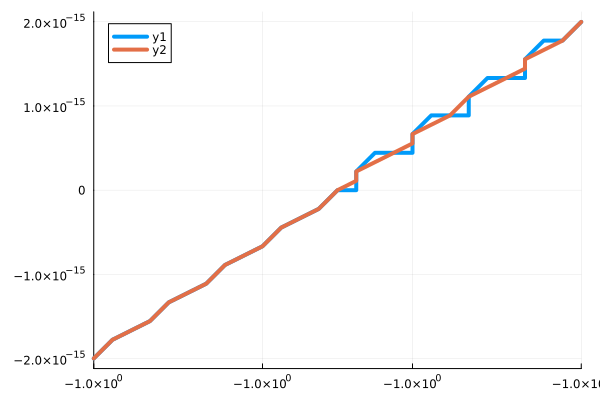

In [24]:
plot([x -> log(2 + x),
      x -> log1p(1 + x)],
    xlims = (-1-2e-15, -1+2e-15))

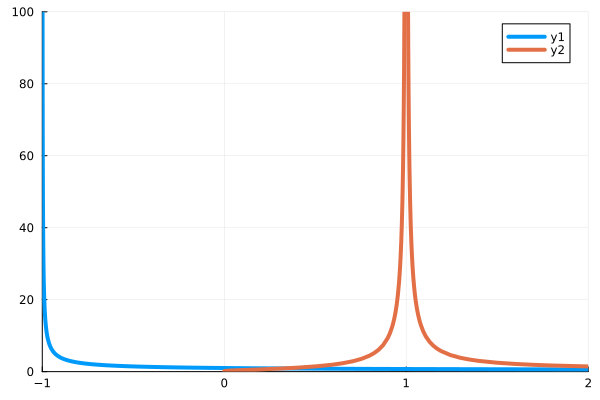

In [5]:
cond1(x) = abs(1/(1+x) * x / log1p(x))
cond2(x) = abs(1/x * x / log(x))
plot([cond1 cond2], xlims=(-1, 2), ylims=(0, 100))

# Reliable = well-conditioned and stable

## Mathematical functions $f(x)$ can be ill-conditioned (big $\kappa$)
* Modeling is how we turn an abstract question into a mathematical function
* We want well-conditioned models (small $\kappa$)
* Some systems are intrinsically sensitive: fracture, chaotic systems, combustion

## Algorithms `f(x)` can be unstable
* Unreliable, though sometimes practical
* Unstable algorithms are constructed from ill-conditioned parts

# An ill-conditioned problem from Paul Olum

From [Surely You're Joking, Mr. Feynman](https://sistemas.fciencias.unam.mx/%7Ecompcuantica/RICHARD%20P.%20FEYNMAN-SURELY%20YOU%27RE%20JOKING%20MR.%20FEYNMAN.PDF) (page 113)

> So Paul is walking past the lunch place and these guys are all excited. "Hey, 
Paul!" they call out. "Feynman's terrific! We give him a problem that can be stated in ten 
seconds, and in a minute he gets the answer to 10 percent. Why don't you give him one?" 
Without hardly stopping, he says, "The tangent of 10 to the 100th." 
I was sunk: you have to divide by pi to 100 decimal places! It was hopeless.

What's the condition number?

$$ \kappa = |f'(x)| \frac{|x|}{|f|} $$

* $f(x) = \tan x$
* $f'(x) = 1 + \tan^2 x$

$$ \kappa = \lvert x \rvert \Bigl( \lvert \tan x \rvert + \bigl\lvert \frac{1}{\tan x} \bigr\rvert \Bigr) > \lvert x \rvert$$

In [25]:
tan(1e100)

-0.4116229628832498

In [29]:
tan(BigFloat("1e100", precision=400))

0.4012319619908143541857543436532949583238702611292440683194415381168718098221194

# Forward and backward error



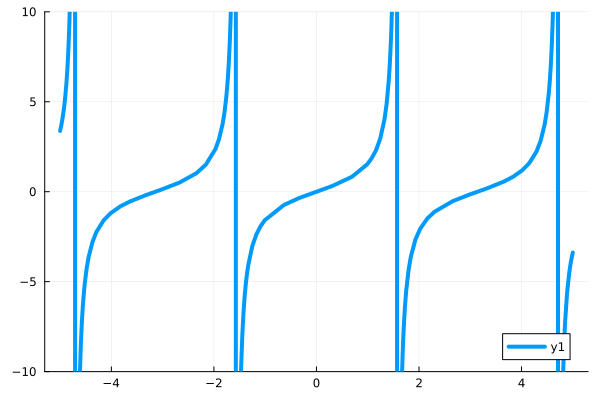

In [8]:
plot(tan, ylims=(-10, 10), x=LinRange(-10, 10, 1000))

## Read [Stability: Backward error](https://fncbook.com/stability/)

![](https://fncbook.com/build/backwarderror-55621e558c526e24b8fc1d61b00b65a3.svg)

* For ill-conditioned functions, the best we can hope for is small backward error.

* Feynman could have answered with any real number and it would have a (relative) backward error less than $10^{-100}$. All the numbers we saw on the previous slide had tiny backward error because

$$ \texttt{tan} \big( \operatorname{fl}(\underbrace{10^{100}}_x) \big) = \tan \big( \underbrace{10^{100} (1 + \epsilon)}_{\tilde x} \big) $$

for some $\epsilon < 10^{-100}$. (All real numbers can be written this way for some small $\epsilon$.)

# Stability
**"nearly the right answer to nearly the right question"**
$$ \frac{\lvert \tilde f(x) - f(\tilde x) \rvert}{| f(\tilde x) |} \in O(\epsilon_{\text{machine}}) $$
for some $\tilde x$ that is close to $x$

## Backward Stability
**"exactly the right answer to nearly the right question"**
$$ \tilde f(x) = f(\tilde x) $$
for some $\tilde x$ that is close to $x$

* Every backward stable algorithm is stable.
* Not every stable algorithm is backward stable.

![](https://fncbook.com/build/backwarderror-55621e558c526e24b8fc1d61b00b65a3.svg)

# Demo: Map angle to the unit circle

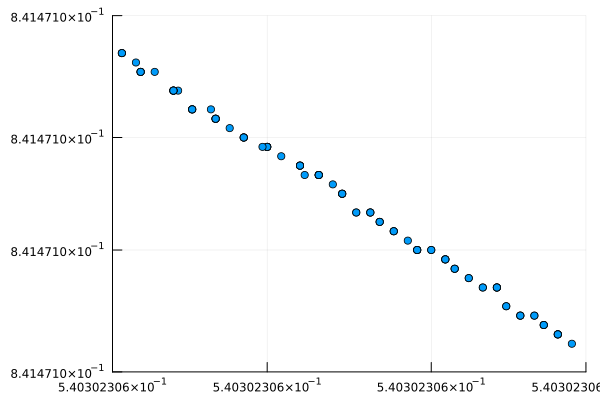

GKS: Possible loss of precision in routine SET_WINDOW


In [9]:
theta = 1 .+ LinRange(0, 8e-15, 100)
scatter(cos.(theta), sin.(theta), legend=:none, aspect_ratio=:equal)

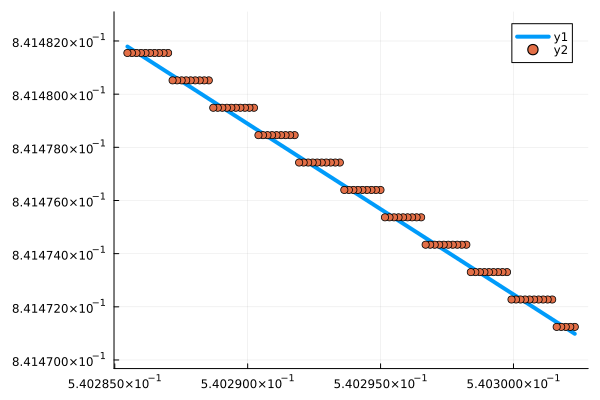

In [10]:
theta = 0 .+ LinRange(1., 1+2e-5, 100)
mysin(t) = cos(t - (1 + 1e10)*pi/2)
plot(cos.(theta), sin.(theta), aspect_ratio=:equal)
scatter!(cos.(theta), mysin.(theta))

## Are we observing A=stability, B=backward stability, or C=neither?

* The numbers $(\widetilde\cos \theta, \widetilde\sin \theta = (\operatorname{fl}(\cos \theta), \operatorname{fl}(\sin\theta))$ do not lie exactly on the unit circles.
  * There does not exist a $\tilde\theta$ such that $(\widetilde\cos \theta, \widetilde \sin\theta) = (\cos\tilde\theta, \sin\tilde\theta)$

## Accuracy of backward stable algorithms (Theorem)

A backward stable algorithm for computing $f(x)$ has relative accuracy
$$ \left\lvert \frac{\tilde f(x) - f(x)}{f(x)} \right\rvert \lesssim \kappa(f) \epsilon_{\text{machine}} . $$
Backward stability is generally the best we can hope for.

In practice, it is rarely possible for a function to be backward stable when the output space is higher dimensional than the input space.

# Go find some functions...

* Find a function $f(x)$ that models something you're interested in
* Plot its condition number $\kappa$ as a function of $x$
* Plot the relative error (using single or double precision; compare using Julia's `big`)
* Is the relative error ever much bigger than $\kappa \epsilon_{\text{machine}}$?
* Can you find what caused the instability?
* Share on Zulip

## Further reading: [FNC Introduction](https://fncbook.com/overview/)

# Stability demo: Volume of a polygon

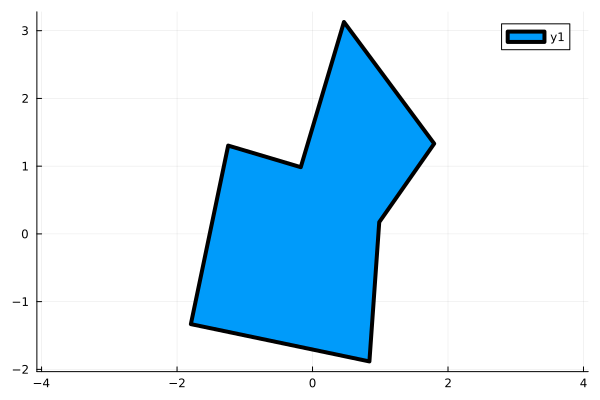

In [14]:
X = ([1 0; 2 1; 1 3; 0 1; -1 1.5; -2 -1; .5 -2; 1 0])
R(θ) = [cos(θ) -sin(θ); sin(θ) cos(θ)]
Y = X * R(deg2rad(10))' # .+ [1e4 1e4]
plot(Y[:,1], Y[:,2], seriestype=:shape, aspect_ratio=:equal)

In [15]:
using LinearAlgebra
function pvolume(X)
    n = size(X, 1)
    vol = sum(det(X[i:i+1, :]) / 2 for i in 1:n-1)
end

@show pvolume(Y)
[det(Y[i:i+1, :]) for i in 1:size(Y, 1)-1]
A = Y[2:3, :]
sum([A[1,1] * A[2,2], - A[1,2] * A[2,1]])
X

pvolume(Y) = 9.25


8×2 Matrix{Float64}:
  1.0   0.0
  2.0   1.0
  1.0   3.0
  0.0   1.0
 -1.0   1.5
 -2.0  -1.0
  0.5  -2.0
  1.0   0.0

What happens if this polygon is translated, perhaps far away?

* Why don't we even get the first digit correct? These numbers are only $10^8$ and $\epsilon_{\text{machine}} \approx 10^{-16}$ so shouldn't we get about 8 digits correct?